# **Multiple Linear Regression, Lasso (L1 Regularization), Ridge (L2 Regularization and ElasticNet)**  

## 1. Linear Regression
- **Goal**: Minimize error (OLS - Ordinary Least Squares).
- **Formula**:  
  $ y = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n $  
- **Problem**: Overfitting with many predictors or multicollinearity.

---

## 2. Ridge Regression (L2 Regularization)
- **Adds L2 Regularization**: Penalizes large coefficients.
- **Formula**:  
  $$ \text{Minimize: } \text{Error} + \lambda \sum \beta_j^2 $$  
- **Key**: Reduces overfitting but keeps all predictors (no zero coefficients).

---

## 3. Lasso Regression (L1 Regularization)
- **Adds L1 Regularization**: Penalizes absolute values of coefficients.
- **Formula**:  
  $$ \text{Minimize: } \text{Error} + \lambda \sum |\beta_j| $$  
- **Key**: Shrinks some coefficients to **exactly zero** (feature selection).

---

## 4. ElasticNet Regression (Combines : L1 + L2)
- **Combination of Ridge and Lasso**: Mix of L1 and L2.
- **Formula**:  
  $$ \text{Minimize: } \text{Error} + \lambda_1 \sum |\beta_j| + \lambda_2 \sum \beta_j^2 $$  
- **Key**: Balances feature selection (Lasso) and stability (Ridge).

---


## ⭐ Model Comparison :

<table style="font-size:18px; width:80%; text-align:left; border:1px solid #ddd; border-collapse:collapse;">
  <tr style="background-color:#f2f2f2;">
    <th style="padding:10px; border:1px solid #ddd;">Model</th>
    <th style="padding:10px; border:1px solid #ddd;">Key Feature</th>
    <th style="padding:10px; border:1px solid #ddd;">Best For</th>
  </tr>
  <tr>
    <td style="padding:10px; border:1px solid #ddd;"><b>Linear</b></td>
    <td style="padding:10px; border:1px solid #ddd;">No regularization</td>
    <td style="padding:10px; border:1px solid #ddd;">Simple problems</td>
  </tr>
  <tr>
    <td style="padding:10px; border:1px solid #ddd;"><b>Ridge</b></td>
    <td style="padding:10px; border:1px solid #ddd;">Shrinks coefficients</td>
    <td style="padding:10px; border:1px solid #ddd;">Multicollinear predictors</td>
  </tr>
  <tr>
    <td style="padding:10px; border:1px solid #ddd;"><b>Lasso</b></td>
    <td style="padding:10px; border:1px solid #ddd;">Feature selection</td>
    <td style="padding:10px; border:1px solid #ddd;">Sparse predictors</td>
  </tr>
  <tr>
    <td style="padding:10px; border:1px solid #ddd;"><b>ElasticNet</b></td>
    <td style="padding:10px; border:1px solid #ddd;">Mix of Ridge & Lasso</td>
    <td style="padding:10px; border:1px solid #ddd;">High-dimensional data</td>
  </tr>
</table>



**`NOTE : ACCURACY IS BAD AS THIS IS JUST A TEMPLATE FOR REFERENCE `**

## **imports, dataframe, train_test_split & standard scaler**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
df = fetch_california_housing()

In [4]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [5]:
dataset = pd.DataFrame(df.data)

In [6]:
dataset.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
dataset.columns = df.feature_names

In [8]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
# Independent Features
X = dataset

# Dependent Feature
y = df.target

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)

In [12]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
## If you want to inverse the scaler (Back to Normal values)
# sc.inverse_transform(X_train)

## **1) LINEAR REGRESSION MODEL**



In [14]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Prediction
linear_y_pred = linear_model.predict(X_test)

In [16]:
# Checking the Accuracy of the model
from sklearn.metrics import r2_score

linear_r2 = r2_score(y_test, linear_y_pred)
print(f"Linear Regression R^2 Score: {linear_r2:.2f}")

Linear Regression R^2 Score: 0.60


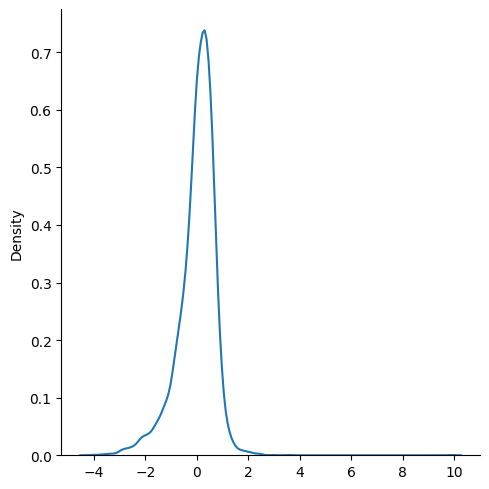

In [17]:
# Visualize Train and Test
sns.displot(linear_y_pred - y_test, kind='kde')

`Note : Accuracy is bad as This is just a practice model :)`

## **2) RIDGE REGRESSION (L2 REGULARIZATION)**



> Best to **prevent overfitting**




In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [19]:
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_model = GridSearchCV(Ridge(), ridge_params, scoring='r2', cv=5)

In [20]:
ridge_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(), param_grid={'alpha': [0.1, 1, 10, 100]},
             scoring='r2')

In [21]:
ridge_best_model = ridge_model.best_estimator_

In [22]:
# Prediction
ridge_y_pred = ridge_best_model.predict(X_test)

In [23]:
score = r2_score(ridge_y_pred, y_test)
score

0.3425458182224228

In [24]:
ridge_r2 = r2_score(y_test, ridge_y_pred)
print(f"Ridge Regression R^2 Score: {ridge_r2:.2f} (Best Alpha: {ridge_model.best_params_['alpha']})")

Ridge Regression R^2 Score: 0.60 (Best Alpha: 10)


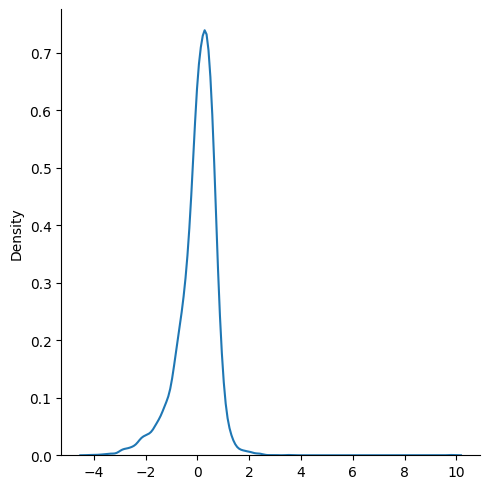

In [25]:
# Visualize Train and Test
sns.displot(ridge_y_pred - y_test, kind='kde')

## **3) LASSO REGRESSION (L1 REGULARIZATION)**


> Best for **feature selection** and to **prevent overfitting**


In [26]:
from sklearn.linear_model import Lasso

In [27]:
lasso_params = {'alpha': [0.1, 1, 10, 100, 1000]}
lasso_model = GridSearchCV(Lasso(max_iter=10000), lasso_params, scoring='r2', cv=5)

In [28]:
lasso_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]}, scoring='r2')

In [29]:
lasso_best_model = lasso_model.best_estimator_

In [30]:
# Prediction
lasso_y_pred = lasso_best_model.predict(X_test)

In [31]:
lasso_r2 = r2_score(y_test, lasso_y_pred)
print(f"Lasso Regression R^2 Score: {lasso_r2:.2f} (Best Alpha: {lasso_model.best_params_['alpha']})")

Lasso Regression R^2 Score: 0.49 (Best Alpha: 0.1)


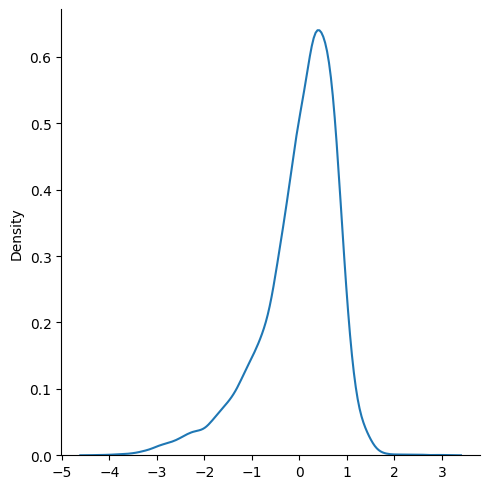

In [32]:
# Visualize Train and Test
sns.displot(lasso_y_pred - y_test, kind='kde')

## **4) ELASTICNET REGRESSOR**



> Combines Lasso and Ridge regularization techniques.

> Uses `alpha` for regularization strength and `l1_ratio` to balance L1 and L2 penalties.

In [33]:
from sklearn.linear_model import ElasticNet

In [34]:
elastic_params = {
    'alpha': [0.1, 1, 10, 100, 1000],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]  # Balance between L1 (Lasso) and L2 (Ridge)
}

In [35]:
elastic_model = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, scoring='r2', cv=5)

In [36]:
elastic_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9]},
             scoring='r2')

In [37]:
elastic_best_model = elastic_model.best_estimator_

In [38]:
elastic_y_pred = elastic_best_model.predict(X_test)

In [39]:
elastic_r2 = r2_score(y_test, elastic_y_pred)

In [40]:
print(f"ElasticNet Regression R^2 Score: {elastic_r2:.2f} (Best Alpha: {elastic_model.best_params_['alpha']}, Best L1_Ratio: {elastic_model.best_params_['l1_ratio']})")

ElasticNet Regression R^2 Score: 0.56 (Best Alpha: 0.1, Best L1_Ratio: 0.1)


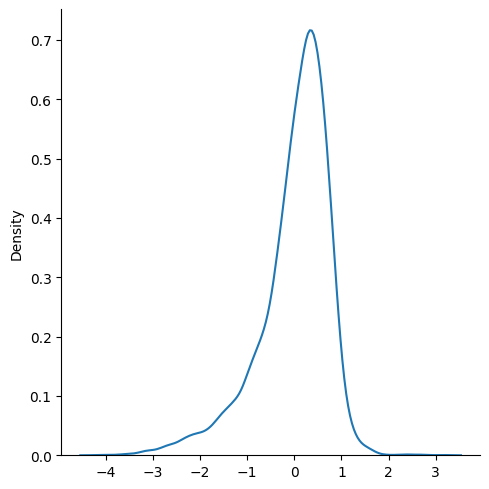

In [41]:
# Visualize Train and Test
sns.displot(elastic_y_pred - y_test, kind='kde')